In [ ]:
# imports
import numpy as np
import pandas as pd

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Classifiers
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
import xgboost as xgb


In [11]:
df = pd.read_csv('..\\data\\train.csv')
df.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


### MI scores

In [26]:
# from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif

In [28]:
def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')
    

### Go

In [29]:
X_full = df.copy()
X_full = X_full.drop(columns=['id'])
y = X_full.pop('IsFraud')

### Standart train test split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [56]:
# Values into arrays for feeding the classification algorithms
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [57]:
# Implement simple classifiers

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
# from xgboost import XGBRegressor

classifiers = {
    "LogisticRegression" : LogisticRegression(),
    "KNearest" : KNeighborsClassifier(),
    "Support Vector Classifier" : SVC(),
    "DecisionTreeClassifier" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    # "XGB boost" : XGBRegressor(),
    "Neural Network" : MLPClassifier(
                                hidden_layer_sizes=(50,50),
                                activation='relu',
                                solver='adam',
                                alpha=1e-3,
                                learning_rate_init=1e-3,
                                early_stopping=True,
                                validation_fraction=0.1,
                                max_iter=500,
                                random_state=0
                            )
}

In [58]:
from sklearn.model_selection import cross_val_score

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "% accuracy score")

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5, scoring='average_precision')
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "average_precision")

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

Classifiers: LogisticRegression Has a training score of 70.0 % accuracy score
Classifiers: KNeighborsClassifier Has a training score of 62.0 % accuracy score
Classifiers: SVC Has a training score of 56.00000000000001 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of 62.0 % accuracy score
Classifiers: RandomForestClassifier Has a training score of 70.0 % accuracy score
Classifiers: MLPClassifier Has a training score of 57.99999999999999 % accuracy score


c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

Classifiers: LogisticRegression Has a training score of 81.0 average_precision
Classifiers: KNeighborsClassifier Has a training score of 64.0 average_precision
Classifiers: SVC Has a training score of 68.0 average_precision
Classifiers: DecisionTreeClassifier Has a training score of 60.0 average_precision
Classifiers: RandomForestClassifier Has a training score of 80.0 average_precision
Classifiers: MLPClassifier Has a training score of 70.0 average_precision


In [59]:
from sklearn.model_selection import GridSearchCV

In [60]:
# User GridSearch to find the best parameters for logistic regression.
log_reg_params = {
    'penalty': ['l1','l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
log_reg = grid_log_reg.best_estimator_

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

In [61]:
print(grid_log_reg.best_params_)
print(grid_log_reg.best_score_)

{'C': 0.1, 'penalty': 'l2'}
0.7046511627906976


In [62]:
# Now lets greed search other classifiers
knears_params = {'n_neighbors': list(range(2,5,1)),'algorithm' : ['auto','ball_tree','kd_tree', 'brute']}
grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train,y_train)
# Knears best estimator
knears_neighbors = grid_knears.best_estimator_

In [63]:
# # Support Vector classifier . Greed search
# svc_params = {'C': [0.5,0.7,0.9,1], 'kernel':['rbf','linear']} #'poly','sigmoid',
# grid_svc = GridSearchCV(SVC(), svc_params, cv=5, n_jobs=-1)
# grid_svc.fit(X_train, y_train)
# svc_params = {'C': [0.5, 1], 'kernel': ['rbf', 'linear']}
# grid_svc = GridSearchCV(SVC(), svc_params)
# grid_svc.fit(X_train, y_train)
# # svc best estimator
# svc = grid_svc.best_estimator_

In [64]:
# Decicion tree best estimator
tree_params = {
    'criterion' : ['gini','entropy'],
    'max_depth' : list(range(2,4,1)),
    'min_samples_leaf' : list(range(5,7,1))
}

grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)
#best estimator
tree_clf = grid_tree.best_estimator_

In [65]:
log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

# svc_score = cross_val_score(svc, X_train, y_train, cv=5)
# print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  70.47%
Knears Neighbors Cross Validation Score 60.23%
DecisionTree Classifier Cross Validation Score 63.26%


c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

In [66]:
# building the pipeline
# model = RandomForestClassifier(n_estimators=100, random_state=0)
# model = LogisticRegression(C=0.01, penalty='l2', max_iter=500)
model = xgb.XGBClassifier()

clf = Pipeline(steps=[
    ('model', model)
])

In [68]:
clf.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [ ]:
preds = clf.predict(X_test)
preds

In [71]:
preds.max()

np.int64(1)

In [72]:
# print('MAE:', mean_absolute_error(y_test,preds))

## Use right metrics for imbalanced classification


In [73]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc

In [74]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.79      0.71      0.75        63
           1       0.65      0.73      0.69        45

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.73      0.72      0.72       108



In [75]:
# 2) ROC AUC for overall separability
probs = clf.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

ROC AUC: 0.7763668430335098


In [76]:
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

PR AUC 0.7210795472419058


In [78]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

<function matplotlib.pyplot.show(close=None, block=None)>

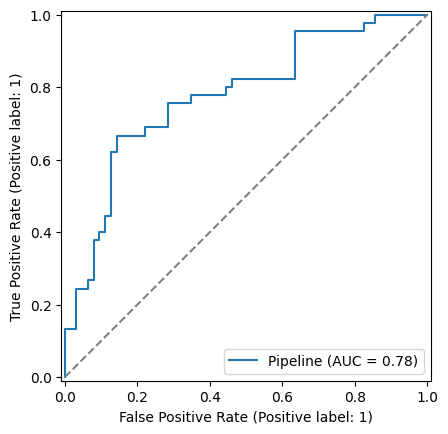

In [79]:
disp = RocCurveDisplay.from_estimator(
    clf, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

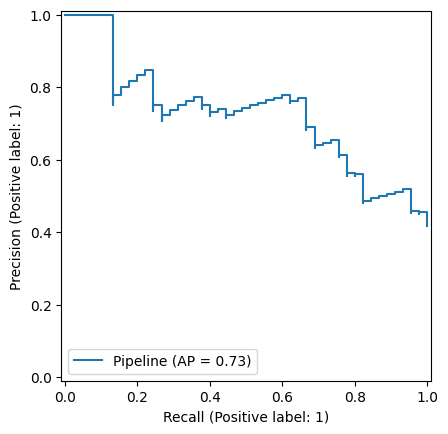

In [80]:
disp2 = PrecisionRecallDisplay.from_estimator(
    clf, X_test, y_test,
)
plt.show()

### Submission

In [ ]:
submission_data = pd.read_csv('credit-card-fraud-prediction\\test.csv')
submission_data.head() # prepare pipeline instead for that

In [ ]:
submission_data2 = submission_data.drop('id', axis=1)
submission_data2.head()

In [87]:
df_for_pipe = pd.read_csv('credit-card-fraud-prediction\\train.csv')
y = df_for_pipe['IsFraud']
X = df_for_pipe.drop(['IsFraud', 'Time', 'id'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [ ]:
# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

preprocessor = ColumnTransformer([
    ("robust_scale", RobustScaler(), ['Transaction_Amount']),
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', clf)
])

pipeline.fit(X_train,y_train)
preds_for_submission = pipeline.predict_proba(submission_data2)

In [89]:
# look at feature importances
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values(ascending=False)

feat4                 0.113960
feat9                 0.048284
feat11                0.043480
feat7                 0.040867
feat10                0.039122
feat1                 0.036616
feat13                0.034840
feat18                0.034244
feat16                0.034103
feat5                 0.033805
feat22                0.032171
feat3                 0.032055
feat8                 0.031211
feat14                0.031191
feat6                 0.030320
feat19                0.030143
Transaction_Amount    0.030051
feat15                0.030004
feat23                0.029498
feat21                0.029069
feat17                0.029020
feat27                0.028914
feat12                0.027713
feat20                0.026878
feat2                 0.025956
feat28                0.025352
feat25                0.024529
feat26                0.023527
feat24                0.023080
dtype: float32

In [91]:
preds_for_submission[:,1]

array([2.0062892e-06, 6.9669459e-06, 8.4326457e-06, ..., 1.2633929e-05,
       2.9029147e-04, 2.8738641e-05], dtype=float32)

In [92]:
preds_for_submission.shape

(69129, 2)

In [93]:
output = pd.DataFrame(
    {
        'id' : submission_data.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)

In [94]:
output.to_csv('submission.csv', index=False)

In [95]:
output[output['IsFraud']==1]

,id,IsFraud


In [96]:
output

,id,IsFraud
0,150000,0.000002
1,150001,0.000007
2,150002,0.000008
3,150003,0.000032
4,150004,0.002267
...,...,...
69124,219124,0.000024
69125,219125,0.005943
69126,219126,0.000013
69127,219127,0.000290
